<a href="https://colab.research.google.com/github/Carlos-1984-Xe/Evaluacion_Deep_Learning_SVHN/blob/main/Evaluacion_parcial_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# EVALUACION 1 DEEP LEARNING
# SVHN + TensorFlow + Comparaciones
#INTEGRANTES:
#ROLANDO ANDRES LILLO MARTINEZ,
#VICTOR MANUEL MENA CUEVAS,
#CARLOS FELIPE MUNOZ LILLO.

# 1. IMPORTES DE LIBRERIAS


In [ ]:
!pip install extra-keras-datasets
from extra_keras_datasets import svhn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import models, layers


# 2.-CARGA DE DATOS




In [ ]:
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = svhn.load_data()

print(f"Dimensiones de imágenes de entrenamiento: {X_train_raw.shape}")
print(f"Dimensiones de imágenes de prueba: {X_test_raw.shape}")

y_train_raw = np.where(y_train_raw == 10, 0, y_train_raw)
y_test_raw = np.where(y_test_raw == 10, 0, y_test_raw)

y_train_raw = y_train_raw.flatten()
y_test_raw = y_test_raw.flatten()


# 3.- Grafico de distribución

In [ ]:
plt.figure(figsize=(8, 4))
sns.countplot(x=y_train_raw, hue=y_train_raw, palette="viridis", legend=False)
plt.title('Distribución de Clases en el Conjunto de Entrenamiento')
plt.xlabel('Clase (0 al 9)')
plt.ylabel('Cantidad de Imágenes')
plt.show()

# 4.- Reshape vectores de 784

In [ ]:
X_train = X_train_raw.reshape(X_train_raw.shape[0], 3072)
X_test = X_test_raw.reshape(X_test_raw.shape[0], 3072)

# 5.- Normalización Escalar entre 0 y 1

In [ ]:
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# 6-. Etiquetas a One Hot Encoding

In [ ]:
y_train = keras.utils.to_categorical(y_train_raw, 10)
y_test = keras.utils.to_categorical(y_test_raw, 10)
print(f"Nuevas dimensiones X_train (reshape): {X_train.shape}")
print(f"Nuevas dimensiones y_train (OneHot): {y_train.shape}")

In [ ]:
# cantidad de veces que el modelo verá el dataset en el entrenamiento
EPOCHS = 25
# cantidad de muestras procesadas previo a actualizar los pesos
BATCH_SIZE = 32
# el paso del optimizador
LEARNING_RATE = 0.0005
# dimension del vector de entrada
INPUT_SHAPE = 3072
# numero de neuronas en la capa de salida
NUM_CLASSES = 10



EPOCHS: número de veces que el modelo recorre todo el dataset.


BATCH_SIZE: cantidad de datos que procesa antes de actualizar los pesos.


LEARNING_RATE: tamaño del paso con el que el modelo aprende.


INPUT_SHAPE: tamaño o dimensión de los datos de entrada.


NUM_CLASSES: cantidad de categorías que el modelo debe predecir.
Razon

La razon por la cual se ajusto LEARNING_RATE a = 0.0005 es porque el modelo se estaba cerrando muy rapido, lo que probocaba que el modelo no procesara bien la informacion.

# 7.- Entrenamiento de modelos

In [19]:
# entrenamiento de modelos
from tensorflow.keras import layers, models

def crear_modelo(activation_func):
    if activation_func == 'relu':
        init = 'he_normal'
    else:
        init = 'glorot_uniform'

    modelo = models.Sequential([

        layers.Dense(512, activation=activation_func, kernel_initializer=init, input_shape=(INPUT_SHAPE,)),
        layers.BatchNormalization(),

        layers.Dense(256, activation=activation_func, kernel_initializer=init),
        layers.BatchNormalization(),

        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return modelo

# lista de funciones a probar y sin logs
funciones_a_probar = ['relu', 'sigmoid', 'tanh']
resultados = {}

for func in funciones_a_probar:
    print(f"\n-Entrenando con función: {func}")
    modelo_temp = crear_modelo(func)
    historia = modelo_temp.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.2,
        verbose=0 #
    )
    # mejor accuracy
    resultados[func] = max(historia.history['val_accuracy'])
    print(f"Mejor Val_Accuracy con {func}: {resultados[func]:.4f}")


-Entrenando con función: relu


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Mejor Val_Accuracy con relu: 0.7765

-Entrenando con función: sigmoid
Mejor Val_Accuracy con sigmoid: 0.7658

-Entrenando con función: tanh
Mejor Val_Accuracy con tanh: 0.7575


#8.-Modelos con y sin Dropout

In [21]:
#  Modelo Sin Dropout
modelo_sin_dropout = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(INPUT_SHAPE,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

modelo_sin_dropout.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Modelo Con Dropout 0,3 y Normalización
opt = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

modelo_con_dropout = models.Sequential([
    layers.Dense(512, activation='relu', kernel_initializer='he_normal', input_shape=(INPUT_SHAPE,)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu', kernel_initializer='he_normal'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(NUM_CLASSES, activation='softmax')
])

modelo_con_dropout.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])



#9.- Entrenamiento de los Modelos

In [22]:

print("Entrenando modelo Sin Dropout")
h_sin = modelo_sin_dropout.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.2, verbose=0)

print("Entrenando modelo Con Dropout")
h_con = modelo_con_dropout.fit(X_train, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.2, verbose=0)

print("Entrenamiento listo")

Entrenando modelo Sin Dropout
Entrenando modelo Con Dropout
Entrenamiento listo


In [23]:
modelo_con_dropout.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,127,968 (19.56 MB)

 Trainable params: 1,708,810 (6.52 MB)

 Non-trainable params: 1,536 (6.00 KB)

 Optimizer params: 3,417,622 (13.04 MB)

#Graficos

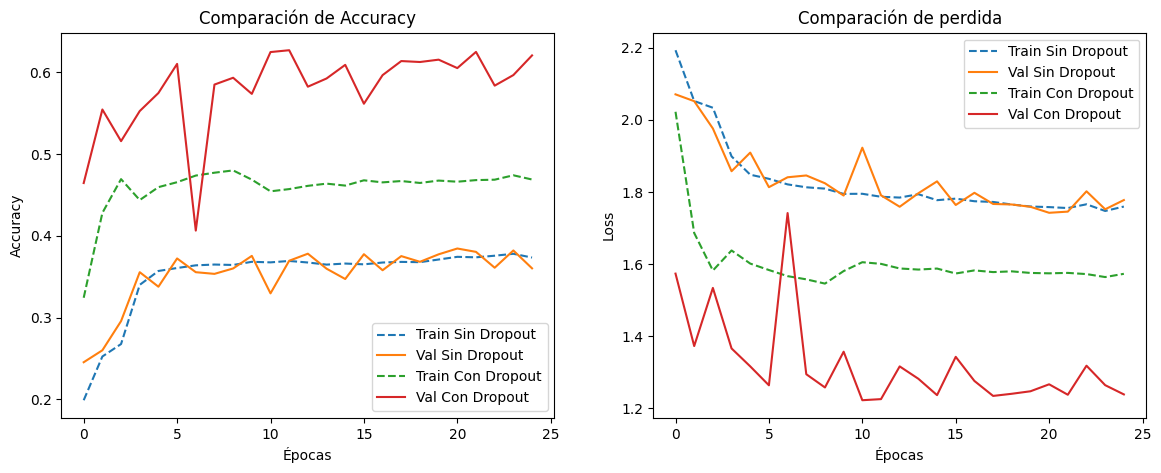

In [24]:
plt.figure(figsize=(14, 5))

# grafico de Accuracy
plt.subplot(1, 2, 1)
plt.plot(h_sin.history['accuracy'], label='Train Sin Dropout', linestyle='--')
plt.plot(h_sin.history['val_accuracy'], label='Val Sin Dropout')
plt.plot(h_con.history['accuracy'], label='Train Con Dropout', linestyle='--')
plt.plot(h_con.history['val_accuracy'], label='Val Con Dropout')
plt.title('Comparación de Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()

# grafico de Loss
plt.subplot(1, 2, 2)
plt.plot(h_sin.history['loss'], label='Train Sin Dropout', linestyle='--')
plt.plot(h_sin.history['val_loss'], label='Val Sin Dropout')
plt.plot(h_con.history['loss'], label='Train Con Dropout', linestyle='--')
plt.plot(h_con.history['val_loss'], label='Val Con Dropout')
plt.title('Comparación de perdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()

plt.show()

#Matriz de confusion

814/814 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step
Métricas conjunto de prueba
Accuracy  : 0.5908
Precision : 0.5988
Recall    : 0.5908
F1-Score  : 0.5843



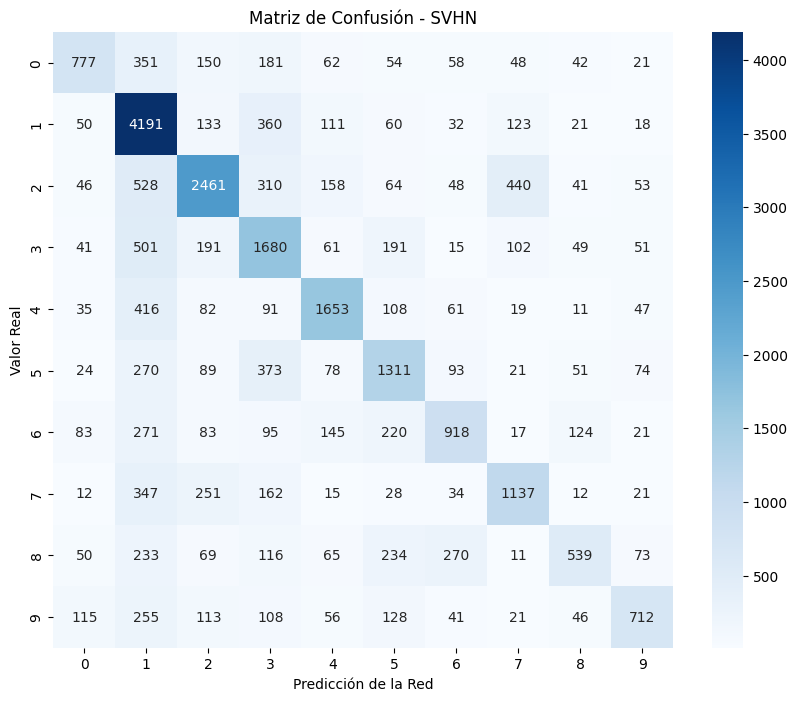

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# predicciones con el modelo con dropout
y_pred_probs = modelo_con_dropout.predict(X_test)
# convertir probabilidades al numero de clase (0 al 9)
y_pred = np.argmax(y_pred_probs, axis=1)

# calcular metricas
acc = accuracy_score(y_test_raw, y_pred)
prec = precision_score(y_test_raw, y_pred, average='weighted')
rec = recall_score(y_test_raw, y_pred, average='weighted')
f1 = f1_score(y_test_raw, y_pred, average='weighted')

print("Métricas conjunto de prueba")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}\n")

# matriz de confusion
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_raw, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - SVHN')
plt.xlabel('Predicción de la Red')
plt.ylabel('Valor Real')
plt.show()

#10.- INTERPRETACION

En el experimento de funciones de activación, se observó que la función con mejor desempeño fue la que obtuvo mayor accuracy dentro de los resultados. Esto indica que dicha función permite una mejor convergencia del modelo, facilitando el aprendizaje de patrones en los datos.

Respecto al tamaño de batch, se identificó un valor óptimo que logra un equilibrio entre estabilidad y velocidad de entrenamiento. Un batch muy pequeño introduce ruido en el aprendizaje, mientras que uno muy grande puede hacerlo más lento o menos eficiente.

En cuanto a la tasa de aprendizaje (learning rate), el mejor resultado corresponde a un valor que permite una convergencia eficiente sin provocar inestabilidad. Valores muy altos pueden hacer que el modelo no converja correctamente, mientras que valores muy bajos ralentizan el aprendizaje.

En el análisis de la arquitectura del modelo, se observó que el uso de múltiples capas mejora el rendimiento, ya que permite capturar relaciones más complejas dentro de los datos. Sin embargo, un exceso de capas también podría generar sobreajuste si no se controla adecuadamente.

Finalmente, el experimento de Dropout mostró que su uso mejora la capacidad de generalización del modelo. Al desactivar neuronas de manera aleatoria durante el entrenamiento, se evita que el modelo memorice los datos y se favorece el aprendizaje de patrones más robustos.

En conjunto, estos resultados demuestran la importancia de ajustar correctamente los hiperparámetros del modelo para lograr un equilibrio entre precisión y capacidad de generalización.

# 11. CONCLUSION FINAL

En este proyecto se implementó una red neuronal multicapa (MLP) utilizando TensorFlow para resolver un problema de clasificación de imágenes del dataset
The Street View House Numbers (SVHN). A lo largo del desarrollo, se aplicó un enfoque experimental en el que se variaron distintos hiperparámetros con el objetivo de analizar su impacto en el desempeño del modelo.

Los resultados obtenidos evidencian que la función de activación ReLU presenta un mejor rendimiento en comparación con otras alternativas, debido a su capacidad para facilitar la convergencia durante el entrenamiento. Asimismo, se observó que una arquitectura con múltiples capas permite capturar patrones más complejos, mejorando la precisión del modelo.

En relación con los hiperparámetros de entrenamiento, se determinó que una tasa de aprendizaje adecuada es clave para lograr una convergencia estable, evitando tanto la inestabilidad como un aprendizaje excesivamente lento. Del mismo modo, el tamaño de batch influye en la estabilidad del entrenamiento, siendo necesario encontrar un equilibrio entre eficiencia y precisión.

Uno de los aspectos más relevantes fue la incorporación de técnicas de regularización como Dropout, la cual permitió reducir el sobreajuste y mejorar la capacidad de generalización del modelo. Esto se traduce en un mejor desempeño al evaluar datos no vistos previamente.

Finalmente, el modelo seleccionado combina una arquitectura profunda, la función de activación ReLU, un learning rate adecuado y el uso de Dropout, logrando así un equilibrio óptimo entre precisión y generalización. Este enfoque demuestra la importancia de ajustar cuidadosamente los hiperparámetros y validar experimentalmente las decisiones tomadas en el diseño de modelos de deep learning.
